In [1]:
# Imports
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (8, 6)

### Data

In [2]:
def first_existing_path(candidates):
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    raise FileNotFoundError("None of these paths exist:\n" + "\n".join(str(Path(c)) for c in candidates))


small_flow_path = first_existing_path([
    "./TrafficProject/results/task3_flow_timeseries_5sec.csv",
    "./TrafficProject/results/task3_flow_timeseries.csv",
    "./Data/TrafficProject/results/task3_flow_timeseries_5sec.csv",
    "./Data/TrafficProject/results/task3_flow_timeseries.csv",
])

combined_flow_path = first_existing_path([
    "../Data_2_v2_combined/results/flow_10s_all.csv",
    "../Data_2_v2/results/flow_10s_all.csv",
    "../Exercise_3/results/flow_10s_all.csv",
    "./Data_2_v2_combined/results/flow_10s_all.csv",
    "./Data_2_v2/results/flow_10s_all.csv",
    "./Exercise_3/results/flow_10s_all.csv",
])

small_raw = pd.read_csv(small_flow_path)
combined_raw = pd.read_csv(combined_flow_path)

required_columns = {"west_in", "east_in", "north_in", "south_in"}
for name, frame in [("small", small_raw), ("combined", combined_raw)]:
    missing = required_columns.difference(frame.columns)
    if missing:
        raise ValueError(f"Missing columns in {name} dataset: {sorted(missing)}")

print(f"Small one-crossroad dataset: {small_flow_path}")
print(f"Bigger combined dataset:     {combined_flow_path}")
combined_raw.head()

Small one-crossroad dataset: TrafficProject\results\task3_flow_timeseries_5sec.csv
Bigger combined dataset:     ..\Exercise_3\results\flow_10s_all.csv


,source_id,time_bin,west_in,east_in,north_in,south_in,total_flow
0,zhandong_road1,0,4,3,1,3,11
1,zhandong_road1,1,4,0,4,3,11
2,zhandong_road1,2,4,0,4,2,10
3,zhandong_road1,3,1,1,2,1,5
4,zhandong_road1,4,2,9,1,0,12


In [3]:
DIRECTIONS = ["north", "south", "east", "west"]
DIRECTION_COLUMNS = {
    "north": "north_in",
    "south": "south_in",
    "east": "east_in",
    "west": "west_in",
}

In [4]:
def summarize_direction_flow(flow_df, dataset_name, source_id=None):
    rows = []
    for direction, column in DIRECTION_COLUMNS.items():
        rows.append({
            "dataset": dataset_name,
            "source_id": source_id if source_id is not None else dataset_name,
            "direction": direction,
            "avg_flow": flow_df[column].mean(),
            "max_flow": flow_df[column].max(),
            "total_flow": flow_df[column].sum(),
        })

    summary = pd.DataFrame(rows)
    summary["flow_share"] = summary["avg_flow"] / summary["avg_flow"].sum()
    return summary

In [5]:
small_summary = summarize_direction_flow(small_raw, "One crossroad small", source_id="crossroad_1")

if "source_id" in combined_raw.columns:
    combined_summaries = []
    for source_id, group in combined_raw.groupby("source_id"):
        combined_summaries.append(summarize_direction_flow(group, "Data_2_v2 combined", source_id=source_id))
    combined_summary = pd.concat(combined_summaries, ignore_index=True)
else:
    combined_summary = summarize_direction_flow(combined_raw, "Data_2_v2 combined", source_id="combined_crossroad")

dataset_summary = pd.concat([small_summary, combined_summary], ignore_index=True)
dataset_summary

,dataset,source_id,direction,avg_flow,max_flow,total_flow,flow_share
0,One crossroad small,crossroad_1,north,35.000000,100,5740,0.153014
1,One crossroad small,crossroad_1,south,16.902439,59,2772,0.073894
2,One crossroad small,crossroad_1,east,94.957317,198,15573,0.415136
3,One crossroad small,crossroad_1,west,81.878049,182,13428,0.357956
4,Data_2_v2 combined,zhandong_road1,north,2.000000,6,168,0.284264
5,Data_2_v2 combined,zhandong_road1,south,0.726190,4,61,0.103215
6,Data_2_v2 combined,zhandong_road1,east,2.404762,9,202,0.341794
7,Data_2_v2 combined,zhandong_road1,west,1.904762,6,160,0.270728
8,Data_2_v2 combined,zhandong_road2,north,2.250000,5,99,0.328904
9,Data_2_v2 combined,zhandong_road2,south,0.750000,3,33,0.109635


### Graph build

In [6]:
ROAD_FEATURES = {
    "north": {"length_m": 95, "lanes": 2, "speed_kmh": 40, "x": 0, "y": 1},
    "south": {"length_m": 90, "lanes": 1, "speed_kmh": 40, "x": 0, "y": -1},
    "east": {"length_m": 120, "lanes": 2, "speed_kmh": 40, "x": 1, "y": 0},
    "west": {"length_m": 115, "lanes": 2, "speed_kmh": 40, "x": -1, "y": 0},
}

In [7]:
def build_traffic_graph(direction_summary, graph_name, center_spacing=3):
    G = nx.DiGraph(name=graph_name)
    node_rows = []
    edge_rows = []

    source_ids = list(direction_summary["source_id"].unique())

    for source_index, source_id in enumerate(source_ids):
        offset_x = source_index * center_spacing
        center_id = f"{source_id}_C"
        center_label = f"{source_id} junction"

        node_rows.append({
            "node_id": center_id,
            "label": center_label,
            "source_id": source_id,
            "node_type": "signalized",
            "x": offset_x,
            "y": 0,
        })

        source_summary = direction_summary[direction_summary["source_id"] == source_id]
        for _, row in source_summary.iterrows():
            direction = row["direction"]
            road = ROAD_FEATURES[direction]
            approach_id = f"{source_id}_{direction[0].upper()}"
            approach_label = f"{source_id} {direction} approach"

            node_rows.append({
                "node_id": approach_id,
                "label": approach_label,
                "source_id": source_id,
                "node_type": "upstream",
                "x": offset_x + road["x"],
                "y": road["y"],
            })

            travel_time_seconds = road["length_m"] / (road["speed_kmh"] * 1000 / 3600)
            capacity_proxy = road["lanes"] * road["speed_kmh"]
            congestion_index = row["avg_flow"] / capacity_proxy

            edge_rows.append({
                "source": approach_id,
                "target": center_id,
                "source_id": source_id,
                "direction": direction,
                "length_m": road["length_m"],
                "lanes": road["lanes"],
                "speed_kmh": road["speed_kmh"],
                "free_flow_time_s": travel_time_seconds,
                "avg_flow": row["avg_flow"],
                "max_flow": row["max_flow"],
                "flow_share": row["flow_share"],
                "congestion_index": congestion_index,
                "edge_type": "approach_in",
            })

            edge_rows.append({
                "source": center_id,
                "target": approach_id,
                "source_id": source_id,
                "direction": direction + "_out",
                "length_m": road["length_m"],
                "lanes": road["lanes"],
                "speed_kmh": road["speed_kmh"],
                "free_flow_time_s": travel_time_seconds,
                "avg_flow": row["avg_flow"] * 0.8,
                "max_flow": row["max_flow"] * 0.8,
                "flow_share": row["flow_share"],
                "congestion_index": congestion_index * 0.8,
                "edge_type": "approach_out",
            })

    # Connect central junctions in the bigger graph to represent nearby-intersection influence.
    if len(source_ids) > 1:
        for left, right in zip(source_ids[:-1], source_ids[1:]):
            left_center = f"{left}_C"
            right_center = f"{right}_C"
            connector_flow = direction_summary[direction_summary["source_id"].isin([left, right])]["avg_flow"].mean()
            for source_node, target_node in [(left_center, right_center), (right_center, left_center)]:
                edge_rows.append({
                    "source": source_node,
                    "target": target_node,
                    "source_id": "network_connector",
                    "direction": "between_intersections",
                    "length_m": 180,
                    "lanes": 2,
                    "speed_kmh": 40,
                    "free_flow_time_s": 180 / (40 * 1000 / 3600),
                    "avg_flow": connector_flow,
                    "max_flow": connector_flow,
                    "flow_share": np.nan,
                    "congestion_index": connector_flow / 80,
                    "edge_type": "connector",
                })

    node_data = pd.DataFrame(node_rows).drop_duplicates("node_id")
    edge_data = pd.DataFrame(edge_rows)

    for _, row in node_data.iterrows():
        G.add_node(row["node_id"], **row.to_dict(), pos=(row["x"], row["y"]))

    for _, row in edge_data.iterrows():
        G.add_edge(row["source"], row["target"], **row.to_dict())

    return G, node_data, edge_data

In [8]:
small_graph, small_nodes, small_edges = build_traffic_graph(small_summary, "One crossroad small graph")
combined_graph, combined_nodes, combined_edges = build_traffic_graph(combined_summary, "Data_2_v2 combined graph")

print(f"Small graph:    {small_graph.number_of_nodes()} nodes, {small_graph.number_of_edges()} edges")
print(f"Combined graph: {combined_graph.number_of_nodes()} nodes, {combined_graph.number_of_edges()} edges")

Small graph:    5 nodes, 8 edges
Combined graph: 10 nodes, 18 edges


In [9]:
def graph_feature_table(G, node_data, edge_data):
    rows = []
    for node in G.nodes:
        incoming_flow = sum(data["avg_flow"] for _, _, data in G.in_edges(node, data=True))
        outgoing_flow = sum(data["avg_flow"] for _, _, data in G.out_edges(node, data=True))
        node_info = G.nodes[node]
        rows.append({
            "node_id": node,
            "label": node_info["label"],
            "source_id": node_info["source_id"],
            "is_signalized": int(node_info["node_type"] == "signalized"),
            "in_degree": G.in_degree(node),
            "out_degree": G.out_degree(node),
            "incoming_flow": incoming_flow,
            "outgoing_flow": outgoing_flow,
            "total_flow": incoming_flow + outgoing_flow,
        })
    return pd.DataFrame(rows)

In [10]:
small_node_features = graph_feature_table(small_graph, small_nodes, small_edges)
combined_node_features = graph_feature_table(combined_graph, combined_nodes, combined_edges)

graph_comparison = pd.DataFrame([
    {
        "graph": "One crossroad small",
        "nodes": small_graph.number_of_nodes(),
        "edges": small_graph.number_of_edges(),
        "signalized_nodes": small_node_features["is_signalized"].sum(),
        "avg_edge_flow": small_edges["avg_flow"].mean(),
        "max_congestion_index": small_edges["congestion_index"].max(),
    },
    {
        "graph": "Data_2_v2 combined",
        "nodes": combined_graph.number_of_nodes(),
        "edges": combined_graph.number_of_edges(),
        "signalized_nodes": combined_node_features["is_signalized"].sum(),
        "avg_edge_flow": combined_edges["avg_flow"].mean(),
        "max_congestion_index": combined_edges["congestion_index"].max(),
    },
])

graph_comparison.head()

,graph,nodes,edges,signalized_nodes,avg_edge_flow,max_congestion_index
0,One crossroad small,5,8,1,51.466006,1.186966
1,Data_2_v2 combined,10,18,2,1.580393,0.030060


### Visualize and Compare the Graphs

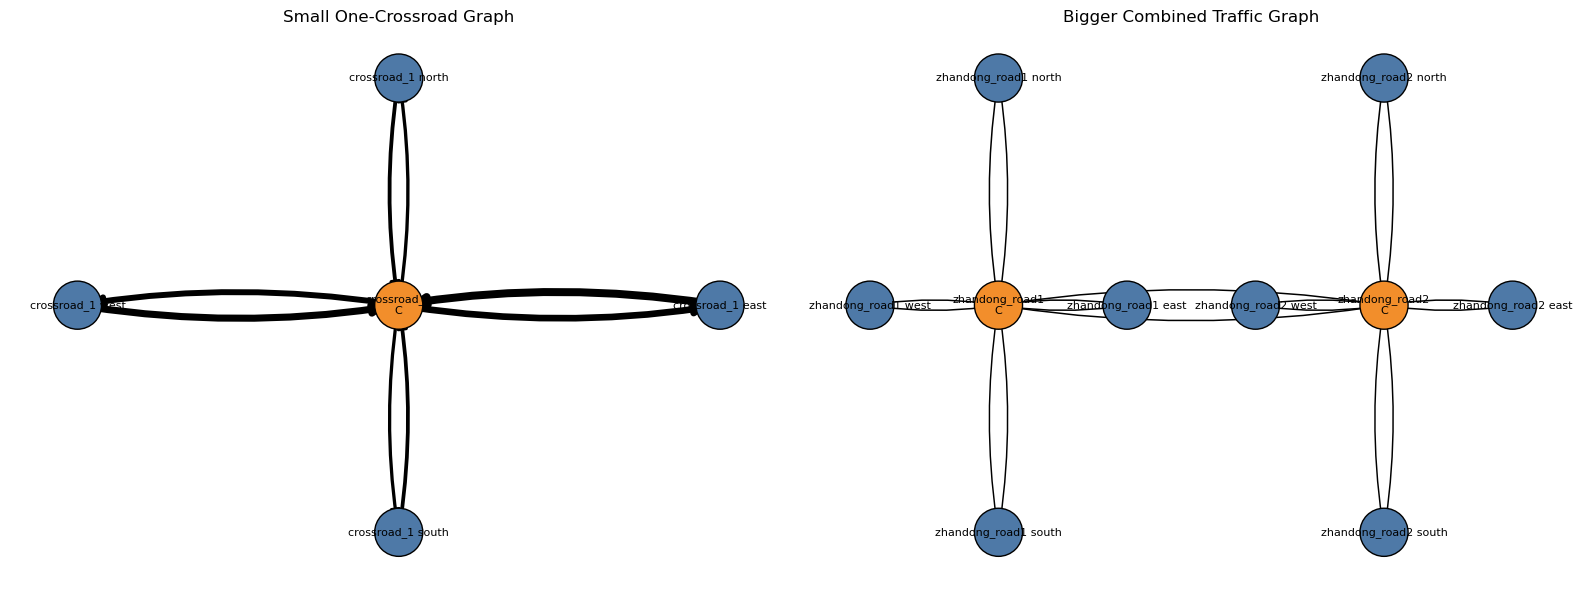

In [11]:
def draw_traffic_graph(G, title, ax):
    pos = nx.get_node_attributes(G, "pos")
    node_colors = ["#f28e2b" if G.nodes[node]["node_type"] == "signalized" else "#4e79a7" for node in G.nodes]
    edge_widths = [1 + 4 * min(G.edges[edge]["congestion_index"], 2) for edge in G.edges]
    labels = {node: G.nodes[node]["label"].replace(" junction", "\nC").replace(" approach", "") for node in G.nodes}

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1200, edgecolors="black", ax=ax)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, ax=ax)
    nx.draw_networkx_edges(G, pos, width=edge_widths, arrows=True, arrowsize=14, connectionstyle="arc3,rad=0.08", ax=ax)
    ax.set_title(title)
    ax.axis("off")


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
draw_traffic_graph(small_graph, "Small One-Crossroad Graph", axes[0])
draw_traffic_graph(combined_graph, "Bigger Combined Traffic Graph", axes[1])
plt.tight_layout()
plt.show()

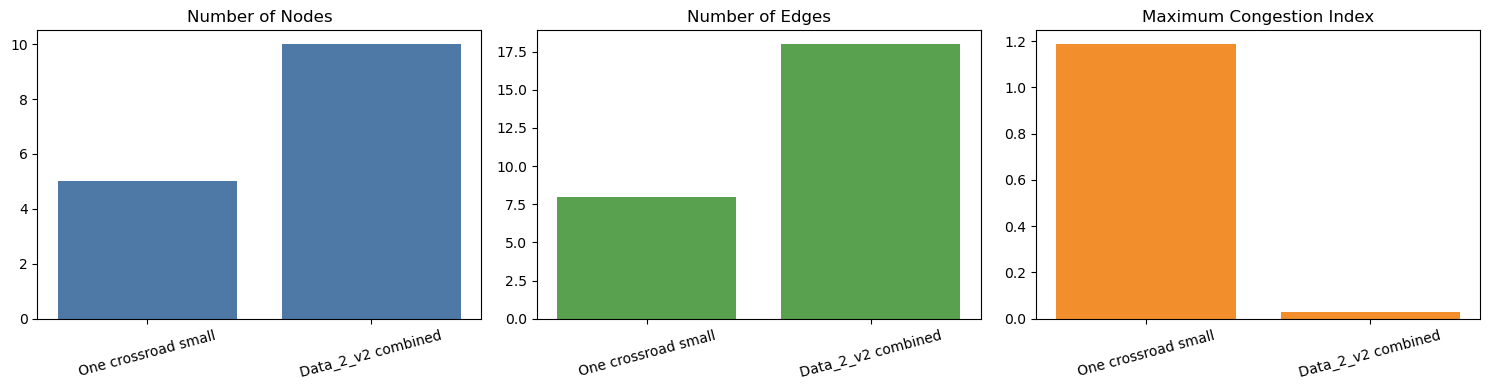

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(graph_comparison["graph"], graph_comparison["nodes"], color="#4e79a7")
axes[0].set_title("Number of Nodes")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(graph_comparison["graph"], graph_comparison["edges"], color="#59a14f")
axes[1].set_title("Number of Edges")
axes[1].tick_params(axis="x", rotation=15)

axes[2].bar(graph_comparison["graph"], graph_comparison["max_congestion_index"], color="#f28e2b")
axes[2].set_title("Maximum Congestion Index")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

### Node and Edge Features

In [13]:
print("Small graph node features")
display(small_node_features)

print("Combined graph node features")
display(combined_node_features)

print("Combined graph edge features")
display(combined_edges.head(12))

Small graph node features


,node_id,label,source_id,is_signalized,in_degree,out_degree,incoming_flow,outgoing_flow,total_flow
0,crossroad_1_C,crossroad_1 junction,crossroad_1,1,4,4,228.737805,182.990244,411.728049
1,crossroad_1_N,crossroad_1 north approach,crossroad_1,0,1,1,28.000000,35.000000,63.000000
2,crossroad_1_S,crossroad_1 south approach,crossroad_1,0,1,1,13.521951,16.902439,30.424390
3,crossroad_1_E,crossroad_1 east approach,crossroad_1,0,1,1,75.965854,94.957317,170.923171
4,crossroad_1_W,crossroad_1 west approach,crossroad_1,0,1,1,65.502439,81.878049,147.380488


Combined graph node features


,node_id,label,source_id,is_signalized,in_degree,out_degree,incoming_flow,outgoing_flow,total_flow
0,zhandong_road1_C,zhandong_road1 junction,zhandong_road1,1,5,5,8.770292,7.363149,16.133442
1,zhandong_road1_N,zhandong_road1 north approach,zhandong_road1,0,1,1,1.600000,2.000000,3.600000
2,zhandong_road1_S,zhandong_road1 south approach,zhandong_road1,0,1,1,0.580952,0.726190,1.307143
3,zhandong_road1_E,zhandong_road1 east approach,zhandong_road1,0,1,1,1.923810,2.404762,4.328571
4,zhandong_road1_W,zhandong_road1 west approach,zhandong_road1,0,1,1,1.523810,1.904762,3.428571
5,zhandong_road2_C,zhandong_road2 junction,zhandong_road2,1,5,5,8.575487,7.207305,15.782792
6,zhandong_road2_N,zhandong_road2 north approach,zhandong_road2,0,1,1,1.800000,2.250000,4.050000
7,zhandong_road2_S,zhandong_road2 south approach,zhandong_road2,0,1,1,0.600000,0.750000,1.350000
8,zhandong_road2_E,zhandong_road2 east approach,zhandong_road2,0,1,1,1.872727,2.340909,4.213636
9,zhandong_road2_W,zhandong_road2 west approach,zhandong_road2,0,1,1,1.200000,1.500000,2.700000


Combined graph edge features


,source,target,source_id,direction,length_m,lanes,speed_kmh,free_flow_time_s,avg_flow,max_flow,flow_share,congestion_index,edge_type
0,zhandong_road1_N,zhandong_road1_C,zhandong_road1,north,95,2,40,8.55,2.000000,6.0,0.284264,0.025000,approach_in
1,zhandong_road1_C,zhandong_road1_N,zhandong_road1,north_out,95,2,40,8.55,1.600000,4.8,0.284264,0.020000,approach_out
2,zhandong_road1_S,zhandong_road1_C,zhandong_road1,south,90,1,40,8.10,0.726190,4.0,0.103215,0.018155,approach_in
3,zhandong_road1_C,zhandong_road1_S,zhandong_road1,south_out,90,1,40,8.10,0.580952,3.2,0.103215,0.014524,approach_out
4,zhandong_road1_E,zhandong_road1_C,zhandong_road1,east,120,2,40,10.80,2.404762,9.0,0.341794,0.030060,approach_in
5,zhandong_road1_C,zhandong_road1_E,zhandong_road1,east_out,120,2,40,10.80,1.923810,7.2,0.341794,0.024048,approach_out
6,zhandong_road1_W,zhandong_road1_C,zhandong_road1,west,115,2,40,10.35,1.904762,6.0,0.270728,0.023810,approach_in
7,zhandong_road1_C,zhandong_road1_W,zhandong_road1,west_out,115,2,40,10.35,1.523810,4.8,0.270728,0.019048,approach_out
8,zhandong_road2_N,zhandong_road2_C,zhandong_road2,north,95,2,40,8.55,2.250000,5.0,0.328904,0.028125,approach_in
9,zhandong_road2_C,zhandong_road2_N,zhandong_road2,north_out,95,2,40,8.55,1.800000,4.0,0.328904,0.022500,approach_out


### Pytorch Geometric

In [14]:
def to_pyg_data(G, node_features, edge_data):
    import torch
    from torch_geometric.data import Data

    node_order = list(G.nodes)
    node_to_index = {node: index for index, node in enumerate(node_order)}
    feature_columns = ["is_signalized", "in_degree", "out_degree", "incoming_flow", "outgoing_flow", "total_flow"]

    x = torch.tensor(node_features.set_index("node_id").loc[node_order, feature_columns].values, dtype=torch.float)
    edge_index = torch.tensor([[node_to_index[u], node_to_index[v]] for u, v in G.edges], dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_data[["length_m", "lanes", "speed_kmh", "free_flow_time_s", "avg_flow", "congestion_index"]].values, dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

In [15]:
try:
    small_pyg_data = to_pyg_data(small_graph, small_node_features, small_edges)
    combined_pyg_data = to_pyg_data(combined_graph, combined_node_features, combined_edges)

    print("Small graph PyG object:")
    print(small_pyg_data)
    print(f"x shape: {small_pyg_data.x.shape}, edge_index shape: {small_pyg_data.edge_index.shape}, edge_attr shape: {small_pyg_data.edge_attr.shape}")
    print()

    print("Combined graph PyG object:")
    print(combined_pyg_data)
    print(f"x shape: {combined_pyg_data.x.shape}, edge_index shape: {combined_pyg_data.edge_index.shape}, edge_attr shape: {combined_pyg_data.edge_attr.shape}")
except ImportError as error:
    print("PyTorch Geometric is not installed in this environment.")
    print("The NetworkX graphs and feature tables above are still enough for the conceptual Task 4 requirement.")
    print(error)

Small graph PyG object:
Data(x=[5, 6], edge_index=[2, 8], edge_attr=[8, 6])
x shape: torch.Size([5, 6]), edge_index shape: torch.Size([2, 8]), edge_attr shape: torch.Size([8, 6])

Combined graph PyG object:
Data(x=[10, 6], edge_index=[2, 18], edge_attr=[18, 6])
x shape: torch.Size([10, 6]), edge_index shape: torch.Size([2, 18]), edge_attr shape: torch.Size([18, 6])


### Conclustion

A GNN learns traffic conditions through connected intersections.
Nodes represent an intersection or connection.
Edges represent roads segments.

GNN is good for global approach. We get upstreams of each road goes to crossroad node and then pass to neighbour crossroad node, in this case neighbour could approximatly guess what ammount of cars will come.
For out project we only studied how for crossroades will effect the crossroad that is between them.

After getting result we can consider that GNN could predict future traffic flow at each node with queue length. Also we can consider that it can calculate probability of congestion spreads to neighboars, trabel time.